# Лабораторная работа №1. Вариант 6

## Разведочный и регрессионный анализ Parkinsons Telemonitoring

Целевая переменная: motor_UPDRS. Признак total_UPDRS не используется среди входов. Модель варианта: GRU. Масштабирование: Min-Max.

Источник данных: UCI Parkinsons Telemonitoring.


## План работы

1. Загрузить библиотеки и данные.
2. Выполнить описательный и визуальный EDA.
3. Найти пропуски, дубликаты, константные и почти нулевые признаки.
4. Очистить данные и показать журнал удалений.
5. Обработать пропуски, создать и отобрать признаки.
6. Сформировать четыре набора данных.
7. Сравнить Dense и GRU по RMSE/R².
8. Проверить лучшую модель на test и выполнить Grid Search для GRU.

Для нейросетевых ячеек требуется TensorFlow/Keras:
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn


In [1]:
# Импорты и воспроизводимость
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
np.random.seed(SEED)

try:
    import tensorflow as tf
    TF_AVAILABLE = True
    tf.keras.utils.set_random_seed(SEED)
except ModuleNotFoundError:
    TF_AVAILABLE = False
    tf = None
    print("TensorFlow не найден: EDA и подготовка данных будут выполнены; модели запустятся после установки TensorFlow.")

TARGET = "motor_UPDRS"
LEAKAGE_COLUMN = "total_UPDRS"
ID_COLUMN = "subject#"
UCI_URL = "https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip"


In [2]:
# Загрузка данных
LOCAL_CANDIDATES = [
    Path("parkinsons_updrs.data"),
    Path("data/parkinsons_updrs.data"),
    Path.home() / "Downloads" / "parkinsons_updrs.data",
]

def load_parkinsons_data(local_candidates=LOCAL_CANDIDATES, url=UCI_URL):
    for candidate in local_candidates:
        if candidate.is_file():
            return pd.read_csv(candidate), f"локальный файл: {candidate}"
    with urlopen(url, timeout=60) as response:
        archive = ZipFile(BytesIO(response.read()))
    data_name = next(n for n in archive.namelist() if n.endswith(".data"))
    with archive.open(data_name) as stream:
        return pd.read_csv(stream), f"UCI: {url}"

df_raw, DATA_SOURCE = load_parkinsons_data()
print(f"Источник: {DATA_SOURCE}")
print(f"Размер исходного набора: {df_raw.shape[0]:,} строк × {df_raw.shape[1]} столбцов")
display(df_raw.head())


Источник: локальный файл: data\parkinsons_updrs.data
Размер исходного набора: 5,875 строк × 22 столбцов


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [3]:
# Первичное знакомство и описательная статистика
display(pd.DataFrame({
    "Показатель": ["Строки", "Столбцы", "Дубликаты", "Пропуски всего", "Числовые столбцы"],
    "Значение": [
        len(df_raw), df_raw.shape[1], int(df_raw.duplicated().sum()),
        int(df_raw.isna().sum().sum()),
        int(df_raw.select_dtypes(include=np.number).shape[1]),
    ],
}))
display(df_raw.dtypes.rename("dtype").to_frame())
display(df_raw.describe().T.round(4))

missing_report = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_share_%": (df_raw.isna().mean() * 100).round(3),
    "unique_count": df_raw.nunique(dropna=False),
    "dtype": df_raw.dtypes.astype(str),
}).sort_values(["missing_count", "unique_count"], ascending=[False, True])
display(missing_report)


,Показатель,Значение
0,Строки,5875
1,Столбцы,22
2,Дубликаты,0
3,Пропуски всего,0
4,Числовые столбцы,22


,dtype
subject#,int64
age,int64
sex,int64
test_time,float64
motor_UPDRS,float64
total_UPDRS,float64
Jitter(%),float64
Jitter(Abs),float64
Jitter:RAP,float64
Jitter:PPQ5,float64


,count,mean,std,min,25%,50%,75%,max
subject#,5875.0,21.4941,12.3723,1.0000,10.0000,22.0000,33.0000,42.0000
age,5875.0,64.8049,8.8215,36.0000,58.0000,65.0000,72.0000,85.0000
sex,5875.0,0.3178,0.4657,0.0000,0.0000,0.0000,1.0000,1.0000
test_time,5875.0,92.8637,53.4456,-4.2625,46.8475,91.5230,138.4450,215.4900
motor_UPDRS,5875.0,21.2962,8.1293,5.0377,15.0000,20.8710,27.5965,39.5110
total_UPDRS,5875.0,29.0189,10.7003,7.0000,21.3710,27.5760,36.3990,54.9920
Jitter(%),5875.0,0.0062,0.0056,0.0008,0.0036,0.0049,0.0068,0.1000
Jitter(Abs),5875.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0004
Jitter:RAP,5875.0,0.0030,0.0031,0.0003,0.0016,0.0022,0.0033,0.0575
Jitter:PPQ5,5875.0,0.0033,0.0037,0.0004,0.0018,0.0025,0.0035,0.0696


,missing_count,missing_share_%,unique_count,dtype
sex,0,0.0,2,int64
age,0,0.0,23,int64
subject#,0,0.0,42,int64
Jitter:PPQ5,0,0.0,840,float64
Shimmer(dB),0,0.0,852,float64
Jitter:RAP,0,0.0,853,float64
motor_UPDRS,0,0.0,1080,float64
total_UPDRS,0,0.0,1129,float64
Jitter(%),0,0.0,1305,float64
Jitter:DDP,0,0.0,1703,float64


## Визуальный разведочный анализ

Ниже приведено больше минимального набора графиков: распределение цели, гистограммы, boxplot, пропуски, корреляционная матрица, корреляции с целью, scatter/regression plots, pairplot по ключевым признакам, число измерений на пациента и динамика цели по времени.


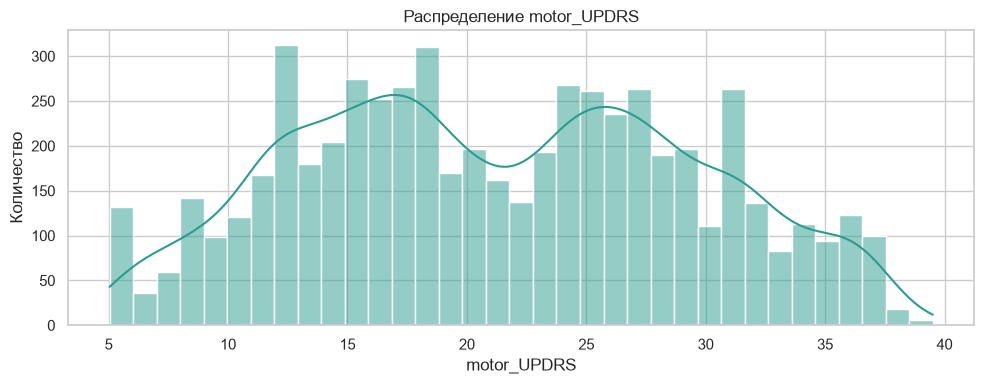

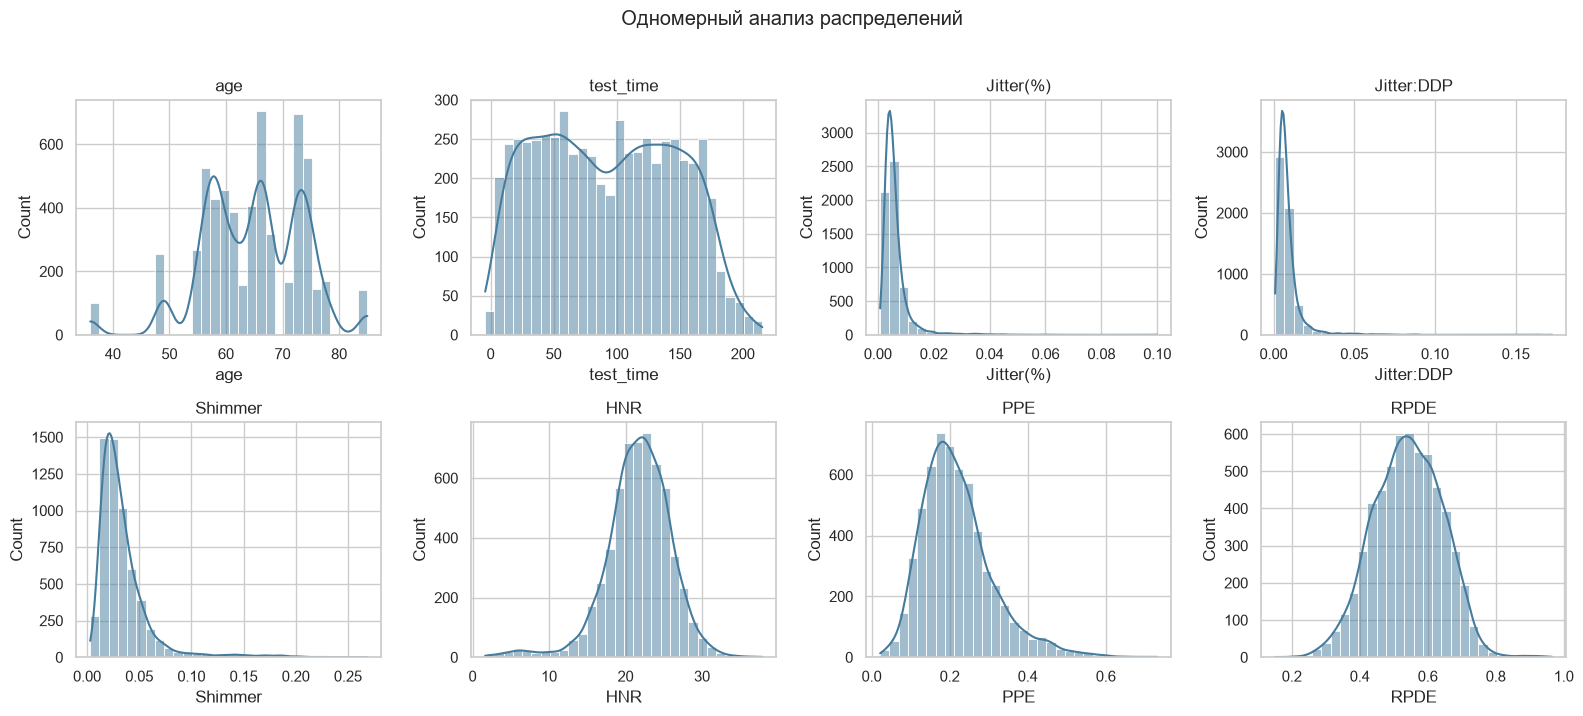

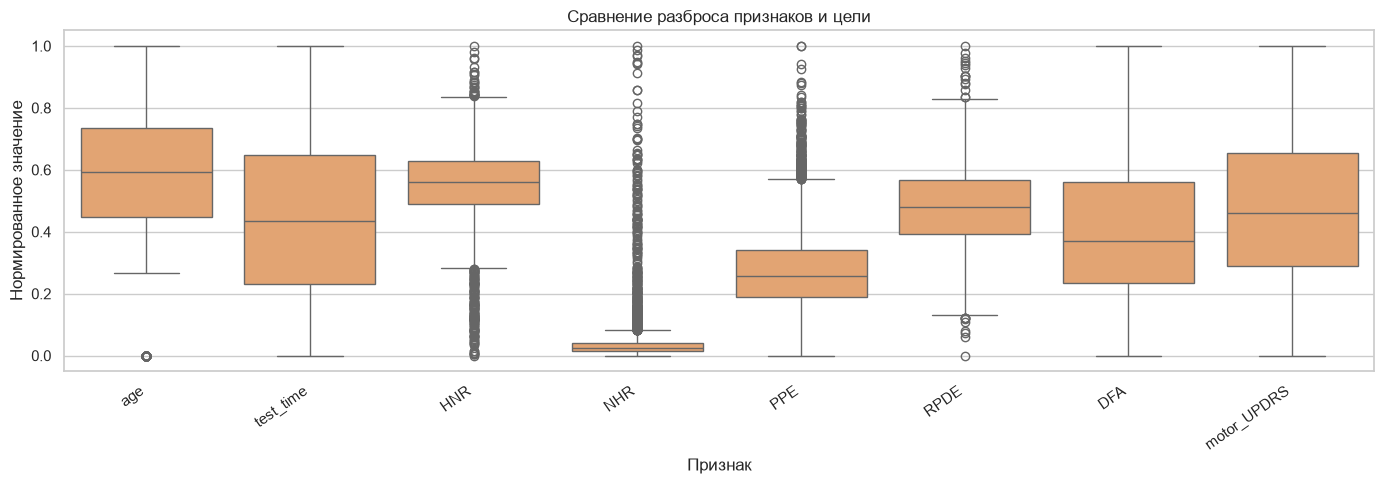

In [4]:
# Графики 1–3: цель, распределения и boxplot
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_raw[TARGET], bins=35, kde=True, ax=ax, color="#2a9d8f")
ax.set(title="Распределение motor_UPDRS", xlabel="motor_UPDRS", ylabel="Количество")
plt.tight_layout(); plt.show()

hist_cols = ["age", "test_time", "Jitter(%)", "Jitter:DDP", "Shimmer", "HNR", "PPE", "RPDE"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, hist_cols):
    sns.histplot(df_raw[col], bins=30, kde=True, ax=ax, color="#457b9d")
    ax.set_title(col)
plt.suptitle("Одномерный анализ распределений", y=1.02)
plt.tight_layout(); plt.show()

box_cols = ["age", "test_time", "HNR", "NHR", "PPE", "RPDE", "DFA", TARGET]
box_norm = (df_raw[box_cols] - df_raw[box_cols].min()) / (df_raw[box_cols].max() - df_raw[box_cols].min())
plt.figure(figsize=(14, 5))
sns.boxplot(data=box_norm.melt(var_name="Признак", value_name="Нормированное значение"),
            x="Признак", y="Нормированное значение", color="#f4a261")
plt.title("Сравнение разброса признаков и цели")
plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()


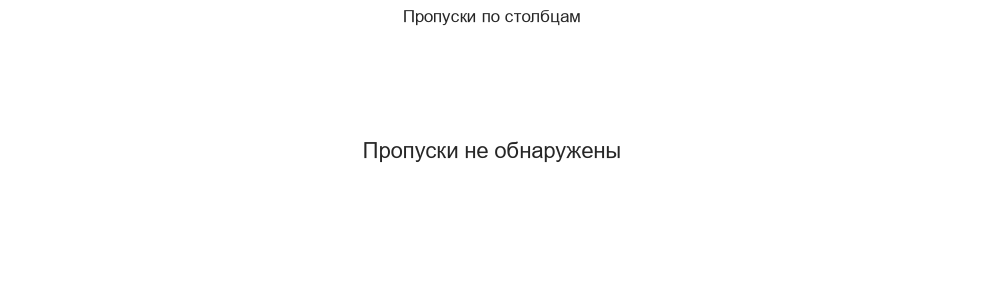

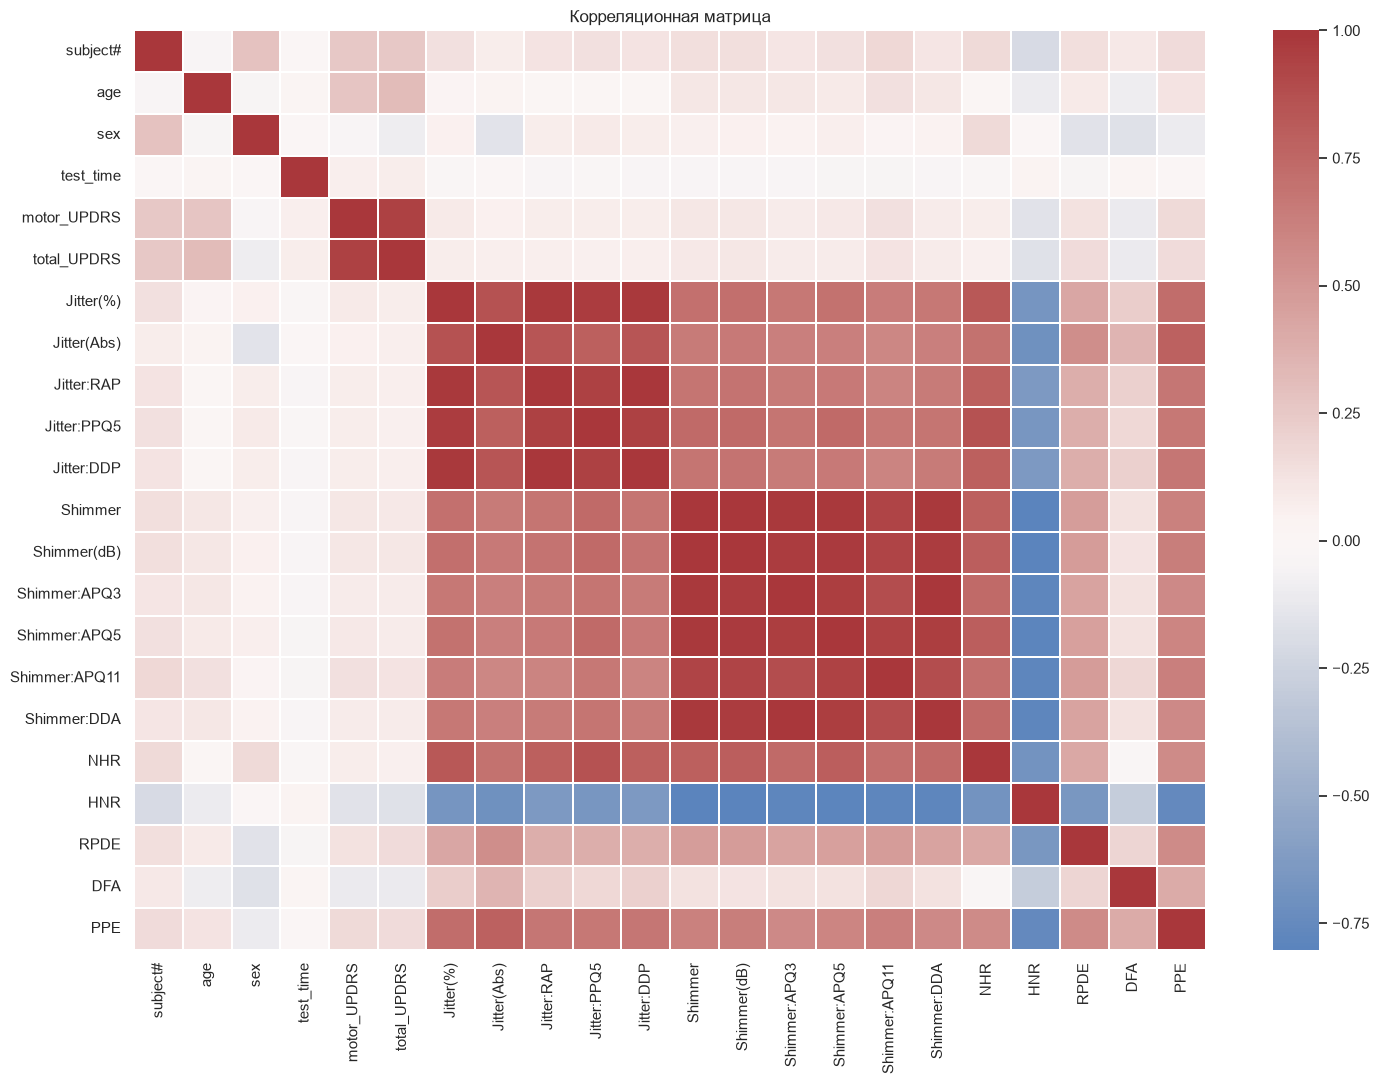

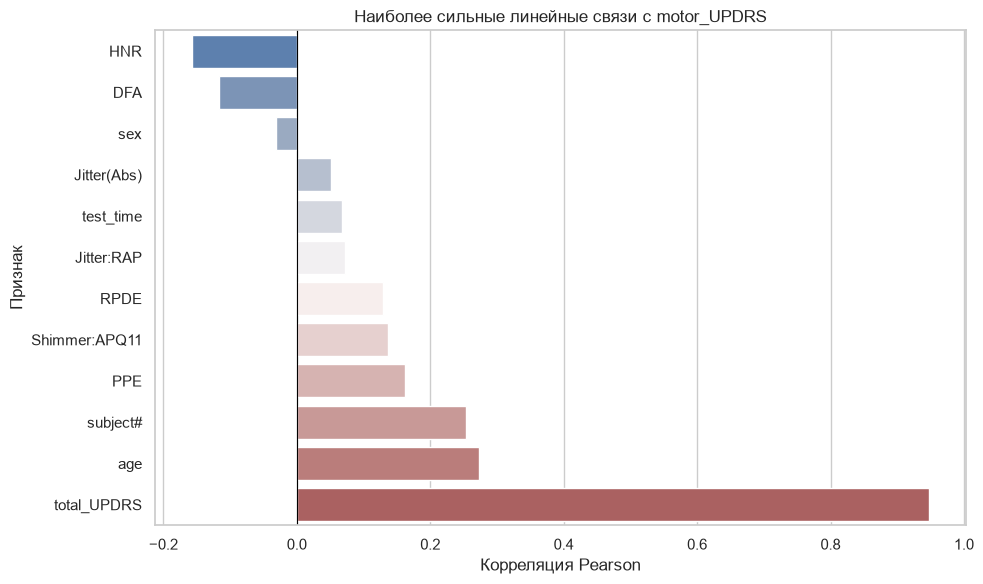

In [5]:
# Графики 4–6: пропуски и корреляции
missing_plot = missing_report[missing_report["missing_count"] > 0]
plt.figure(figsize=(10, 3))
if missing_plot.empty:
    plt.text(0.5, 0.5, "Пропуски не обнаружены", ha="center", va="center", fontsize=16)
    plt.axis("off")
else:
    sns.barplot(x=missing_plot.index, y=missing_plot["missing_count"], color="#e76f51")
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Количество пропусков")
plt.title("Пропуски по столбцам")
plt.tight_layout(); plt.show()

corr = df_raw.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15, 11))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.2)
plt.title("Корреляционная матрица")
plt.tight_layout(); plt.show()

target_corr = corr[TARGET].drop(TARGET).sort_values()
top_corr = pd.concat([target_corr.head(6), target_corr.tail(6)]).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Наиболее сильные линейные связи с motor_UPDRS")
plt.xlabel("Корреляция Pearson"); plt.ylabel("Признак")
plt.tight_layout(); plt.show()


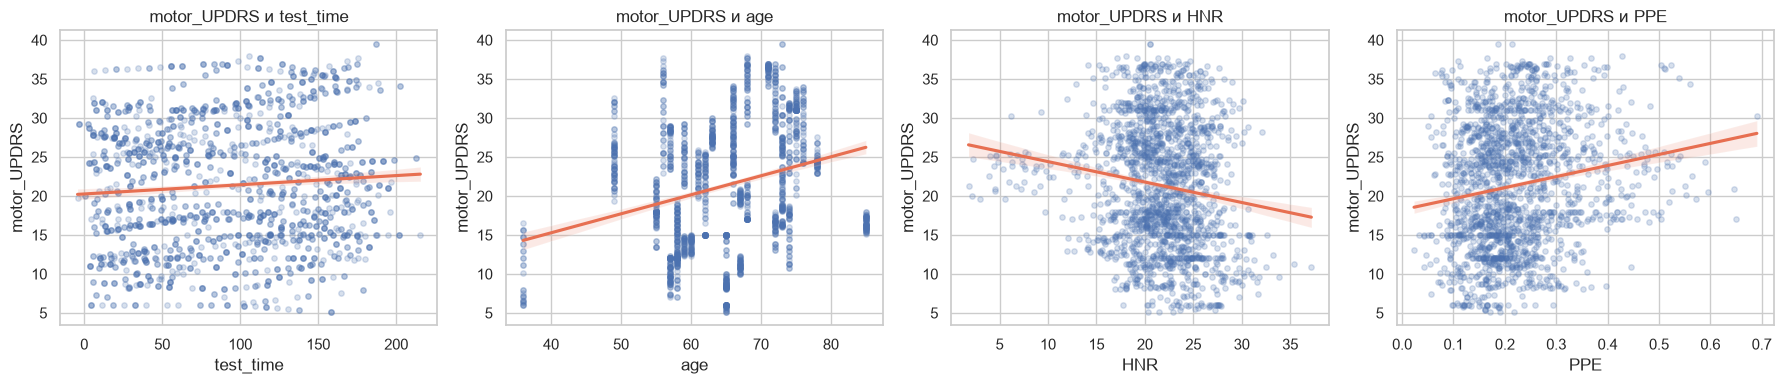

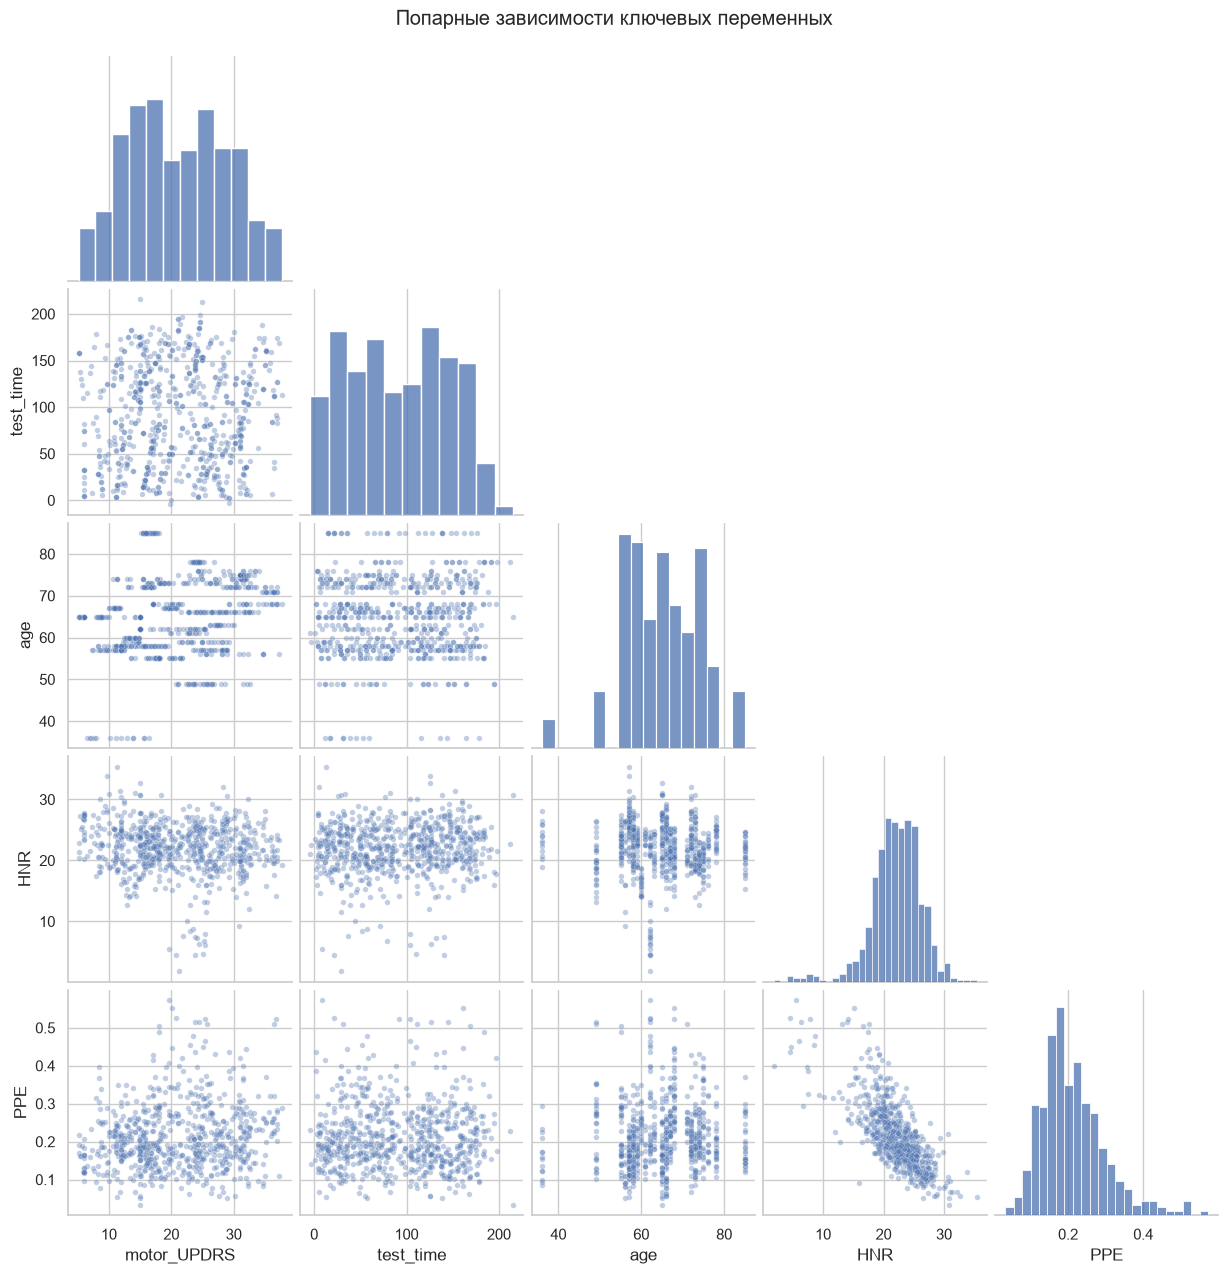

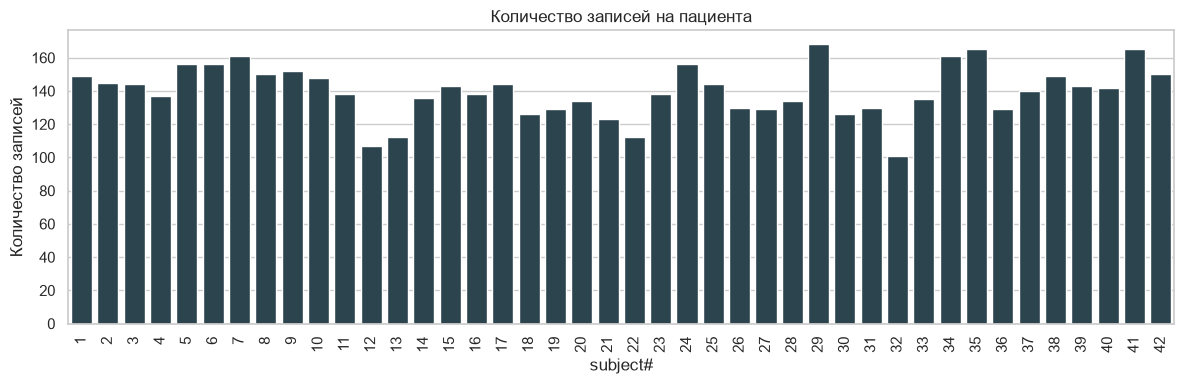

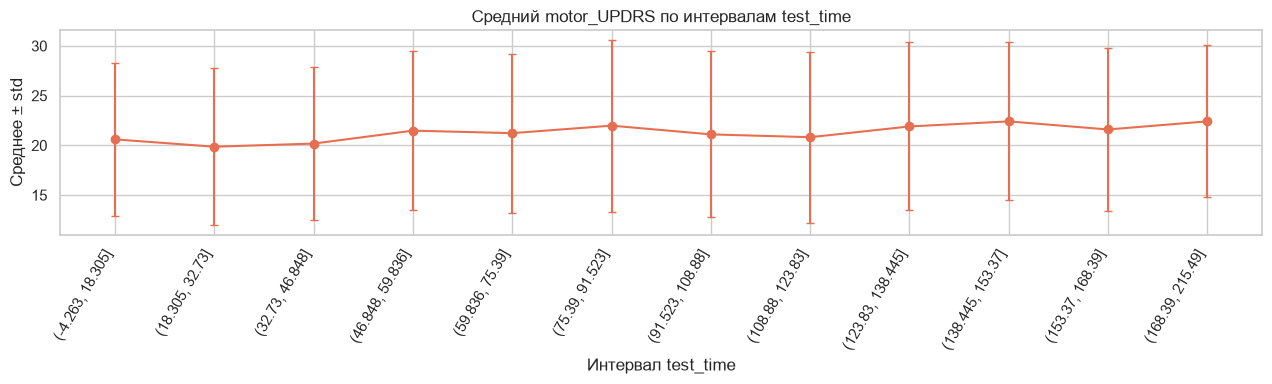

In [6]:
# Графики 7–10: многомерные зависимости и динамика
scatter_cols = ["test_time", "age", "HNR", "PPE"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sample = df_raw.sample(min(1800, len(df_raw)), random_state=SEED)
for ax, col in zip(axes, scatter_cols):
    sns.regplot(data=sample, x=col, y=TARGET, scatter_kws={"alpha": 0.22, "s": 15},
                line_kws={"color": "#e76f51"}, ax=ax)
    ax.set_title(f"{TARGET} и {col}")
plt.tight_layout(); plt.show()

pair_cols = ["motor_UPDRS", "test_time", "age", "HNR", "PPE"]
sns.pairplot(df_raw[pair_cols].sample(min(700, len(df_raw)), random_state=SEED),
             corner=True, plot_kws={"alpha": 0.35, "s": 16})
plt.suptitle("Попарные зависимости ключевых переменных", y=1.02)
plt.show()

subject_counts = df_raw[ID_COLUMN].value_counts().sort_index()
plt.figure(figsize=(12, 4))
sns.barplot(x=subject_counts.index.astype(str), y=subject_counts.values, color="#264653")
plt.title("Количество записей на пациента")
plt.xlabel("subject#"); plt.ylabel("Количество записей")
plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

time_bins = pd.qcut(df_raw["test_time"], q=12, duplicates="drop")
time_summary = df_raw.assign(time_bin=time_bins).groupby("time_bin", observed=True)[TARGET].agg(["mean", "std"]).reset_index()
time_summary["label"] = time_summary["time_bin"].astype(str)
plt.figure(figsize=(13, 4))
plt.errorbar(range(len(time_summary)), time_summary["mean"], yerr=time_summary["std"],
             marker="o", capsize=3, color="#e76f51")
plt.xticks(range(len(time_summary)), time_summary["label"], rotation=60, ha="right")
plt.title("Средний motor_UPDRS по интервалам test_time")
plt.xlabel("Интервал test_time"); plt.ylabel("Среднее ± std")
plt.tight_layout(); plt.show()


## Очистка данных и журнал удалений

Почти нулевым считается числовой признак, у которого одно уникальное значение либо доля уникальных значений не превышает 1%, а одно значение занимает не менее 99% строк. subject# удаляется как идентификатор, total_UPDRS — как запрещённая вариантом 6 утечка целевой информации.


In [7]:
# Поиск константных и почти нулевых признаков
def quasi_constant_report(frame, exclude=None, unique_share_threshold=0.01, dominant_share_threshold=0.99):
    exclude = set(exclude or [])
    rows = []
    for col in frame.select_dtypes(include=np.number).columns:
        if col in exclude:
            continue
        unique_share = frame[col].nunique(dropna=False) / len(frame)
        dominant_share = frame[col].value_counts(dropna=False, normalize=True).iloc[0]
        is_constant = frame[col].nunique(dropna=False) <= 1
        is_quasi = is_constant or (unique_share <= unique_share_threshold and dominant_share >= dominant_share_threshold)
        rows.append({
            "feature": col,
            "unique_count": int(frame[col].nunique(dropna=False)),
            "unique_share_%": round(unique_share * 100, 3),
            "dominant_share_%": round(dominant_share * 100, 3),
            "is_constant_or_near_zero": is_quasi,
        })
    return pd.DataFrame(rows).sort_values(["is_constant_or_near_zero", "unique_share_%"], ascending=[False, True])

near_zero_report = quasi_constant_report(df_raw, exclude=[TARGET, LEAKAGE_COLUMN])
display(near_zero_report)
near_zero_features = near_zero_report.loc[near_zero_report["is_constant_or_near_zero"], "feature"].tolist()


,feature,unique_count,unique_share_%,dominant_share_%,is_constant_or_near_zero
2,sex,2,0.034,68.221,False
1,age,23,0.391,7.302,False
0,subject#,42,0.715,2.860,False
7,Jitter:PPQ5,840,14.298,0.545,False
10,Shimmer(dB),852,14.502,0.562,False
6,Jitter:RAP,853,14.519,0.630,False
4,Jitter(%),1305,22.213,0.374,False
8,Jitter:DDP,1703,28.987,0.289,False
3,test_time,2442,41.566,0.255,False
11,Shimmer:APQ3,2664,45.345,0.170,False


In [8]:
# Очистка и полный журнал удаления признаков
df_clean = df_raw.drop_duplicates().copy()
duplicate_rows_removed = len(df_raw) - len(df_clean)
removal_log_rows = []

for col, reason in [
    (ID_COLUMN, "идентификатор пациента; не является измеряемым признаком"),
    (LEAKAGE_COLUMN, "утечка целевой информации; запрещён входным условием варианта 6"),
]:
    if col in df_clean.columns:
        removal_log_rows.append({"feature": col, "reason": reason})

for col in near_zero_features:
    if col not in {ID_COLUMN, LEAKAGE_COLUMN} and col in df_clean.columns:
        removal_log_rows.append({"feature": col, "reason": "константный или почти нулевой признак по зафиксированному порогу"})

removed_columns = [row["feature"] for row in removal_log_rows]
df_clean = df_clean.drop(columns=removed_columns, errors="ignore")
removal_log = pd.DataFrame(removal_log_rows, columns=["feature", "reason"])

print(f"Удалено дубликатов строк: {duplicate_rows_removed}")
print(f"Размер после очистки: {df_clean.shape[0]:,} × {df_clean.shape[1]}")
display(removal_log if not removal_log.empty else
        pd.DataFrame({"feature": ["<признаки не удалялись>"], "reason": ["Дополнительных удалений не найдено"]}))
display(df_clean.isna().sum().loc[lambda s: s > 0].rename("missing_count").to_frame())


Удалено дубликатов строк: 0
Размер после очистки: 5,875 × 20


,feature,reason
0,subject#,идентификатор пациента; не является измеряемым...
1,total_UPDRS,утечка целевой информации; запрещён входным ус...


,missing_count


## Разбиение, построение и преобразование признаков

Импьютер, Min-Max масштабировщик и отбор признаков обучаются только на train-части. Это исключает утечку статистик validation/test в процесс обучения.


In [9]:
# Train / validation / test
X_full = df_clean.drop(columns=[TARGET])
y_full = df_clean[TARGET].astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(X_full, y_full, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)
print({"train": X_train.shape, "validation": X_val.shape, "test": X_test.shape})


{'train': (4112, 19), 'validation': (881, 19), 'test': (882, 19)}


In [10]:
# Построение дополнительных признаков
def add_engineered_features(frame):
    out = frame.copy()
    jitter_cols = [c for c in ["Jitter(%)", "Jitter(Abs)", "Jitter:RAP", "Jitter:PPQ5", "Jitter:DDP"] if c in frame]
    shimmer_cols = [c for c in ["Shimmer", "Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5", "Shimmer:APQ11", "Shimmer:DDA"] if c in frame]
    if jitter_cols:
        out["jitter_mean"] = frame[jitter_cols].mean(axis=1)
        out["jitter_max"] = frame[jitter_cols].max(axis=1)
    if shimmer_cols:
        out["shimmer_mean"] = frame[shimmer_cols].mean(axis=1)
        out["shimmer_max"] = frame[shimmer_cols].max(axis=1)
    if {"NHR", "HNR"}.issubset(frame.columns):
        out["noise_to_harmonics_ratio"] = frame["NHR"] / (frame["HNR"].abs() + 1e-6)
    if {"age", "test_time"}.issubset(frame.columns):
        out["age_x_test_time"] = frame["age"] * frame["test_time"]
    return out.replace([np.inf, -np.inf], np.nan)

X_train_engineered = add_engineered_features(X_train)
X_val_engineered = add_engineered_features(X_val)
X_test_engineered = add_engineered_features(X_test)
print(f"Признаков до построения: {X_train.shape[1]}; после построения: {X_train_engineered.shape[1]}")


Признаков до построения: 19; после построения: 25


In [11]:
# Медианная импутация и отбор существенных признаков по F-test
def fit_select_k_best(X_fit, y_fit, X_other, k=15):
    imputer = SimpleImputer(strategy="median")
    X_fit_imp = imputer.fit_transform(X_fit)
    X_other_imp = imputer.transform(X_other)
    selector = SelectKBest(score_func=f_regression, k=min(k, X_fit_imp.shape[1]))
    X_fit_sel = selector.fit_transform(X_fit_imp, y_fit)
    X_other_sel = selector.transform(X_other_imp)
    scores = pd.DataFrame({
        "feature": X_fit.columns,
        "F_score": selector.scores_,
        "p_value": selector.pvalues_,
        "selected": selector.get_support(),
    }).sort_values("F_score", ascending=False)
    return X_fit_sel, X_other_sel, imputer, selector, scores

X_train_built, X_val_built, built_imputer, built_selector, feature_scores = fit_select_k_best(
    X_train_engineered, y_train, X_val_engineered, k=15
)
X_test_built = built_selector.transform(built_imputer.transform(X_test_engineered))
display(feature_scores.head(20).round(6))
print(f"Отобрано существенных признаков: {X_train_built.shape[1]}")


,feature,F_score,p_value,selected
0,age,334.694259,0.000000,True
15,HNR,113.923078,0.000000,True
18,PPE,110.324720,0.000000,True
12,Shimmer:APQ11,76.682056,0.000000,True
16,RPDE,71.902743,0.000000,True
24,age_x_test_time,66.953453,0.000000,True
17,DFA,56.272407,0.000000,True
9,Shimmer(dB),48.103844,0.000000,True
22,shimmer_max,48.103844,0.000000,True
21,shimmer_mean,45.336251,0.000000,True


Отобрано существенных признаков: 15


In [12]:
# Четыре набора: исходный, преобразованный исходный, построенный, преобразованный построенный
def impute_split(X_fit, X_val_part, X_test_part):
    imp = SimpleImputer(strategy="median")
    return imp.fit_transform(X_fit), imp.transform(X_val_part), imp.transform(X_test_part), imp

Xtr_original, Xv_original, Xt_original, original_imputer = impute_split(X_train, X_val, X_test)
Xtr_engineered, Xv_engineered, Xt_engineered, engineered_imputer = impute_split(
    X_train_engineered, X_val_engineered, X_test_engineered
)
original_scaler = MinMaxScaler().fit(Xtr_original)
built_scaler = MinMaxScaler().fit(X_train_built)

dataset_variants = {
    "original": {
        "X_train": Xtr_original, "X_val": Xv_original, "X_test": Xt_original,
        "description": "очищенные исходные признаки + медианная импутация",
    },
    "transformed_original": {
        "X_train": original_scaler.transform(Xtr_original),
        "X_val": original_scaler.transform(Xv_original),
        "X_test": original_scaler.transform(Xt_original),
        "description": "исходные признаки + импутация + Min-Max",
    },
    "built": {
        "X_train": X_train_built, "X_val": X_val_built, "X_test": X_test_built,
        "description": "построенные признаки + F-test отбор",
    },
    "transformed_built": {
        "X_train": built_scaler.transform(X_train_built),
        "X_val": built_scaler.transform(X_val_built),
        "X_test": built_scaler.transform(X_test_built),
        "description": "построенные/отобранные признаки + Min-Max",
    },
}
variant_report = pd.DataFrame([
    {"dataset": name, "train_rows": d["X_train"].shape[0],
     "features": d["X_train"].shape[1], "description": d["description"]}
    for name, d in dataset_variants.items()
])
display(variant_report)
assert all(np.isfinite(d["X_train"]).all() and np.isfinite(d["X_val"]).all() and np.isfinite(d["X_test"]).all()
           for d in dataset_variants.values())


,dataset,train_rows,features,description
0,original,4112,19,очищенные исходные признаки + медианная импутация
1,transformed_original,4112,19,исходные признаки + импутация + Min-Max
2,built,4112,15,построенные признаки + F-test отбор
3,transformed_built,4112,15,построенные/отобранные признаки + Min-Max


## Нейросетевые модели

Сравниваются регуляризованная полносвязная сеть Dense и GRU из варианта 6. Для каждой модели используются MSE, L2-регуляризация, Dropout, EarlyStopping и ReduceLROnPlateau.

Поскольку строки являются отдельными табличными измерениями, GRU получает форму samples × 1 × features: один временной шаг содержит весь вектор признаков.


In [13]:
# Функции моделей и метрик
EPOCHS = 80
BATCH_SIZE = 64

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

def build_dense_model(n_features, learning_rate=1e-3, dropout=0.15):
    if not TF_AVAILABLE:
        raise RuntimeError("Установите TensorFlow для Dense.")
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    return model

def build_gru_model(n_features, units=64, learning_rate=1e-3, dropout=0.15):
    if not TF_AVAILABLE:
        raise RuntimeError("Установите TensorFlow для GRU.")
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1, n_features)),
        tf.keras.layers.GRU(units, dropout=dropout, recurrent_dropout=0.0,
                            kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    return model

def fit_neural_model(model, Xtr, ytr, Xv, yv, recurrent=False):
    Xtr_model = Xtr.reshape(-1, 1, Xtr.shape[1]) if recurrent else Xtr
    Xv_model = Xv.reshape(-1, 1, Xv.shape[1]) if recurrent else Xv
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6),
    ]
    return model.fit(Xtr_model, ytr, validation_data=(Xv_model, yv), epochs=EPOCHS,
                     batch_size=BATCH_SIZE, verbose=0, callbacks=callbacks)

def predict_neural_model(model, X, recurrent=False):
    X_model = X.reshape(-1, 1, X.shape[1]) if recurrent else X
    return model.predict(X_model, verbose=0).ravel()


In [14]:
# Обучение Dense и GRU на четырёх наборах
model_store, history_store, comparison_rows = {}, {}, []

if not TF_AVAILABLE:
    display(Markdown("**Модели пока не обучены:** установите TensorFlow и перезапустите ноутбук с этой ячейки."))
    comparison_results = pd.DataFrame(columns=["dataset", "model", "train_RMSE", "train_R2", "val_RMSE", "val_R2"])
else:
    for dataset_name, dataset in dataset_variants.items():
        for model_name, builder, recurrent in [
            ("Dense", build_dense_model, False), ("GRU", build_gru_model, True)
        ]:
            tf.keras.backend.clear_session()
            tf.keras.utils.set_random_seed(SEED)
            model = builder(dataset["X_train"].shape[1])
            history = fit_neural_model(model, dataset["X_train"], y_train.values,
                                       dataset["X_val"], y_val.values, recurrent)
            train_m = regression_metrics(y_train, predict_neural_model(model, dataset["X_train"], recurrent))
            val_m = regression_metrics(y_val, predict_neural_model(model, dataset["X_val"], recurrent))
            comparison_rows.append({
                "dataset": dataset_name, "model": model_name,
                "train_RMSE": train_m["RMSE"], "train_R2": train_m["R2"],
                "val_RMSE": val_m["RMSE"], "val_R2": val_m["R2"],
                "epochs_used": len(history.history["loss"]),
            })
            model_store[(dataset_name, model_name)] = model
            history_store[(dataset_name, model_name)] = history
    comparison_results = pd.DataFrame(comparison_rows).sort_values("val_RMSE")
    display(comparison_results.round(4))


,dataset,model,train_RMSE,train_R2,val_RMSE,val_R2,epochs_used
2,transformed_original,Dense,6.3173,0.3995,6.1638,0.3907,80
6,transformed_built,Dense,6.7589,0.3126,6.6222,0.2967,80
1,original,GRU,7.4922,0.1553,7.3121,0.1426,80
3,transformed_original,GRU,7.7112,0.1052,7.4525,0.1093,80
7,transformed_built,GRU,7.7593,0.0940,7.4983,0.0983,35
4,built,Dense,7.9478,0.0495,7.7574,0.0350,62
5,built,GRU,8.1449,0.0018,7.8843,0.0031,30
0,original,Dense,8.1910,-0.0096,8.0569,-0.0410,23


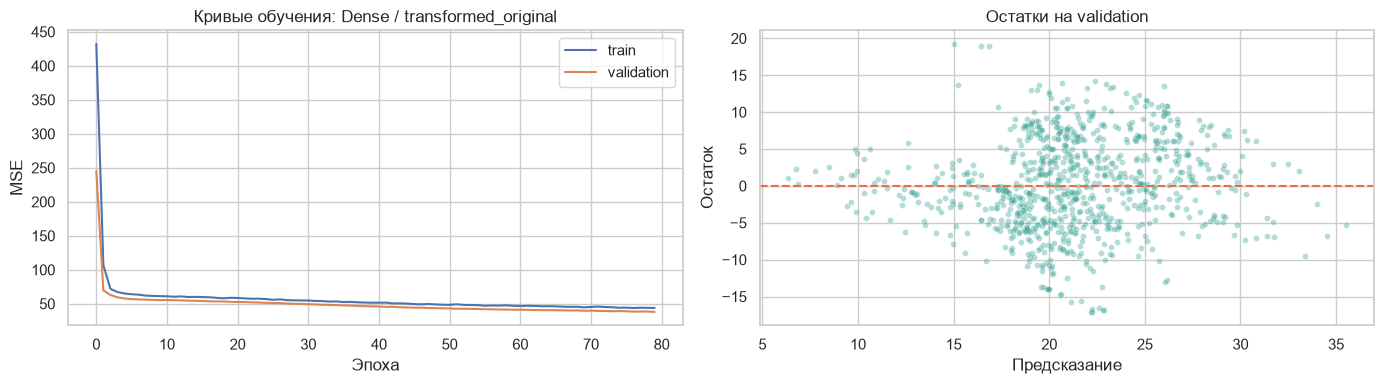

In [15]:
# Кривые обучения и остатки лучшей validation-модели
if TF_AVAILABLE and not comparison_results.empty:
    best_row = comparison_results.iloc[0]
    best_key = (best_row["dataset"], best_row["model"])
    history = history_store[best_key]
    recurrent = best_key[1] == "GRU"
    pred = predict_neural_model(model_store[best_key], dataset_variants[best_key[0]]["X_val"], recurrent)
    residuals = y_val.values - pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validation")
    axes[0].set(title=f"Кривые обучения: {best_key[1]} / {best_key[0]}", xlabel="Эпоха", ylabel="MSE")
    axes[0].legend()
    sns.scatterplot(x=pred, y=residuals, alpha=0.35, s=18, ax=axes[1], color="#2a9d8f")
    axes[1].axhline(0, color="#e76f51", linestyle="--")
    axes[1].set(title="Остатки на validation", xlabel="Предсказание", ylabel="Остаток")
    plt.tight_layout(); plt.show()
else:
    print("Кривые обучения будут построены после установки TensorFlow.")


In [16]:
# Test-оценка лучшей validation-модели
if TF_AVAILABLE and not comparison_results.empty:
    best_row = comparison_results.iloc[0]
    best_key = (best_row["dataset"], best_row["model"])
    best_test_pred = predict_neural_model(
        model_store[best_key], dataset_variants[best_key[0]]["X_test"], best_key[1] == "GRU"
    )
    best_test_metrics = regression_metrics(y_test, best_test_pred)
    print(f"Лучшая validation-модель: {best_key[1]} на наборе {best_key[0]}")
    display(pd.DataFrame([best_test_metrics], index=["test"]).round(4))
else:
    best_test_metrics = {}
    print("Test-оценка будет выполнена после обучения моделей.")


Лучшая validation-модель: Dense на наборе transformed_original


,RMSE,R2
test,6.3015,0.4155


## Grid Search для GRU

GridSearchCV выполняется на train+validation лучшего по validation RMSE набора GRU. Test-выборка остаётся нетронутой до финальной оценки.


In [17]:
# sklearn-совместимая оболочка GRU
class GRURegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=32, dropout=0.1, learning_rate=1e-3, batch_size=64, epochs=50, verbose=0):
        self.units = units
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.verbose = verbose

    def fit(self, X, y):
        if not TF_AVAILABLE:
            raise RuntimeError("Установите TensorFlow для GridSearchCV.")
        X = np.asarray(X, dtype=np.float32)
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        self.model_ = build_gru_model(X.shape[1], units=self.units,
                                      learning_rate=self.learning_rate, dropout=self.dropout)
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
        ]
        self.model_.fit(X.reshape(-1, 1, X.shape[1]), np.asarray(y), validation_split=0.15,
                        epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose, callbacks=callbacks)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        return self.model_.predict(X.reshape(-1, 1, X.shape[1]), verbose=0).ravel()


In [18]:
# Запуск Grid Search и финальная оценка настроенной GRU
if TF_AVAILABLE and not comparison_results.empty:
    gru_rows = comparison_results[comparison_results["model"] == "GRU"].sort_values("val_RMSE")
    best_gru_dataset = gru_rows.iloc[0]["dataset"]
    grid_data = dataset_variants[best_gru_dataset]
    X_trainval = np.vstack([grid_data["X_train"], grid_data["X_val"]]).astype(np.float32)
    y_trainval = np.concatenate([y_train.values, y_val.values]).astype(np.float32)

    grid_search = GridSearchCV(
        GRURegressor(batch_size=64, epochs=50, verbose=0),
        param_grid={"units": [32, 64], "dropout": [0.0, 0.2], "learning_rate": [1e-3]},
        scoring="neg_root_mean_squared_error", cv=3, n_jobs=1, return_train_score=True,
    )
    grid_search.fit(X_trainval, y_trainval)
    tuned_test_metrics = regression_metrics(y_test, grid_search.best_estimator_.predict(grid_data["X_test"]))
    baseline = gru_rows.iloc[0]
    baseline_gru_test_metrics = regression_metrics(
        y_test,
        predict_neural_model(model_store[(best_gru_dataset, "GRU")], grid_data["X_test"], recurrent=True),
    )
    before_after = pd.DataFrame([
        {"stage": "GRU до Grid Search (test)", "RMSE": baseline_gru_test_metrics["RMSE"], "R2": baseline_gru_test_metrics["R2"]},
        {"stage": "GRU после Grid Search", "RMSE": tuned_test_metrics["RMSE"], "R2": tuned_test_metrics["R2"]},
    ])
    print("Лучшие гиперпараметры:", grid_search.best_params_)
    display(before_after.round(4))
    display(pd.DataFrame([tuned_test_metrics], index=["tuned_test"]).round(4))
else:
    grid_search = None
    tuned_test_metrics = {}
    print("Grid Search будет выполнен после установки TensorFlow.")


Лучшие гиперпараметры: {'dropout': 0.0, 'learning_rate': 0.001, 'units': 64}


,stage,RMSE,R2
0,GRU до Grid Search (test),7.6574,0.1369
1,GRU после Grid Search,7.5841,0.1534


,RMSE,R2
tuned_test,7.5841,0.1534


## Полноценная временная постановка для GRU

В предыдущем эксперименте каждая строка подавалась как последовательность длиной 1. Теперь записи группируются по пациентам и сортируются по test_time. Каждые 10 прошлых измерений используются для прогноза следующего motor_UPDRS. Разбиение выполняется по пациентам, чтобы один пациент не оказался одновременно в train и test.


Форма последовательностей: {'train': (3817, 10, 19), 'validation': (745, 10, 19), 'test': (893, 10, 19)}
Пациенты: {'train': 29, 'validation': 6, 'test': 7}
Признаки на одном временном шаге: ['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


Метрики GRU на временных рядах: {'RMSE': 6.8311, 'R2': -0.8116}


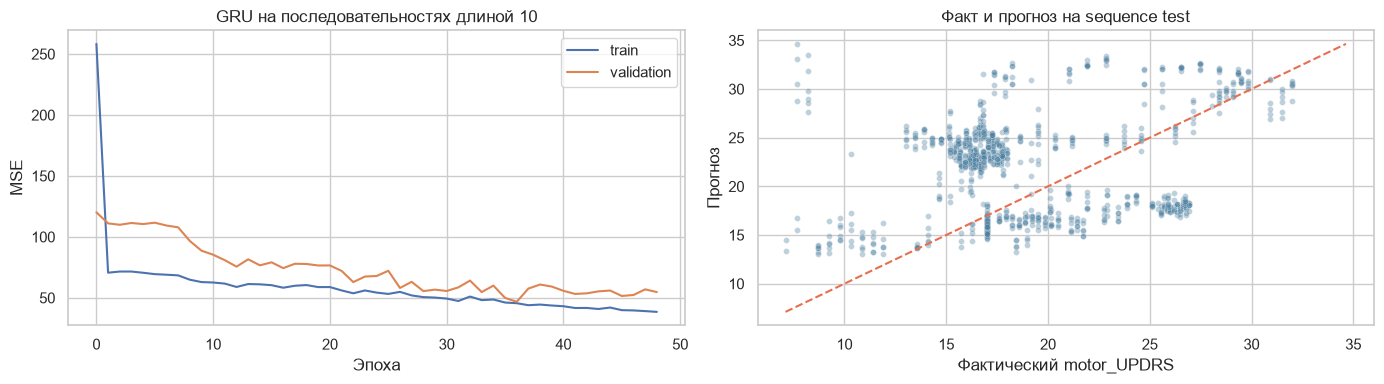

In [19]:
# Преобразование табличных измерений в временные последовательности и обучение GRU
SEQUENCE_LENGTH = 10
sequence_df = df_raw.drop_duplicates().sort_values([ID_COLUMN, "test_time"]).copy()
sequence_feature_cols = [c for c in df_clean.columns if c != TARGET]

subject_ids = sequence_df[ID_COLUMN].unique()
subject_train, subject_temp = train_test_split(subject_ids, test_size=0.30, random_state=SEED)
subject_val, subject_test = train_test_split(subject_temp, test_size=0.50, random_state=SEED)

sequence_imputer = SimpleImputer(strategy="median")
sequence_scaler = MinMaxScaler()
train_rows = sequence_df[sequence_df[ID_COLUMN].isin(subject_train)]
sequence_imputer.fit(train_rows[sequence_feature_cols])
sequence_scaler.fit(sequence_imputer.transform(train_rows[sequence_feature_cols]))
sequence_df[sequence_feature_cols] = sequence_scaler.transform(
    sequence_imputer.transform(sequence_df[sequence_feature_cols])
)

def make_patient_sequences(frame, subjects, feature_cols, target, sequence_length):
    X_seq, y_seq, groups = [], [], []
    for subject, group in frame[frame[ID_COLUMN].isin(subjects)].groupby(ID_COLUMN):
        group = group.sort_values("test_time")
        values = group[feature_cols].to_numpy(dtype=np.float32)
        targets = group[target].to_numpy(dtype=np.float32)
        for end in range(sequence_length, len(group)):
            X_seq.append(values[end-sequence_length:end])
            y_seq.append(targets[end])
            groups.append(subject)
    return np.asarray(X_seq), np.asarray(y_seq), np.asarray(groups)

X_seq_train, y_seq_train, groups_train = make_patient_sequences(
    sequence_df, subject_train, sequence_feature_cols, TARGET, SEQUENCE_LENGTH
)
X_seq_val, y_seq_val, groups_val = make_patient_sequences(
    sequence_df, subject_val, sequence_feature_cols, TARGET, SEQUENCE_LENGTH
)
X_seq_test, y_seq_test, groups_test = make_patient_sequences(
    sequence_df, subject_test, sequence_feature_cols, TARGET, SEQUENCE_LENGTH
)

print("Форма последовательностей:", {
    "train": X_seq_train.shape,
    "validation": X_seq_val.shape,
    "test": X_seq_test.shape,
})
print("Пациенты:", {"train": len(subject_train), "validation": len(subject_val), "test": len(subject_test)})
print("Признаки на одном временном шаге:", sequence_feature_cols)

if TF_AVAILABLE:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    sequence_gru = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, len(sequence_feature_cols))),
        tf.keras.layers.GRU(64, dropout=0.15, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(1),
    ])
    sequence_gru.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    sequence_callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6),
    ]
    sequence_history = sequence_gru.fit(
        X_seq_train, y_seq_train,
        validation_data=(X_seq_val, y_seq_val),
        epochs=80, batch_size=64, verbose=0, callbacks=sequence_callbacks,
    )
    sequence_test_pred = sequence_gru.predict(X_seq_test, verbose=0).ravel()
    sequence_test_metrics = regression_metrics(y_seq_test, sequence_test_pred)
    print("Метрики GRU на временных рядах:", {k: round(v, 4) for k, v in sequence_test_metrics.items()})

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(sequence_history.history["loss"], label="train")
    axes[0].plot(sequence_history.history["val_loss"], label="validation")
    axes[0].set(title="GRU на последовательностях длиной 10", xlabel="Эпоха", ylabel="MSE")
    axes[0].legend()
    sns.scatterplot(x=y_seq_test, y=sequence_test_pred, alpha=0.35, s=18, ax=axes[1], color="#457b9d")
    limits = [min(y_seq_test.min(), sequence_test_pred.min()), max(y_seq_test.max(), sequence_test_pred.max())]
    axes[1].plot(limits, limits, "--", color="#e76f51")
    axes[1].set(title="Факт и прогноз на sequence test", xlabel="Фактический motor_UPDRS", ylabel="Прогноз")
    plt.tight_layout(); plt.show()
else:
    sequence_gru = None
    sequence_history = None
    sequence_test_metrics = {}
    print("Установите TensorFlow для обучения последовательностной GRU.")


In [20]:
# Сравнение табличной GRU и последовательностной GRU
if TF_AVAILABLE and not comparison_results.empty:
    tabular_gru = comparison_results[comparison_results["model"] == "GRU"].sort_values("val_RMSE").iloc[0]
    sequence_comparison = pd.DataFrame([
        {"model": "GRU: одна строка как 1 шаг", "dataset": tabular_gru["dataset"],
         "RMSE": float(tabular_gru["val_RMSE"]), "R2": float(tabular_gru["val_R2"]), "sample": "validation"},
        {"model": "GRU: окно 10 измерений", "dataset": "patient time series",
         "RMSE": sequence_test_metrics["RMSE"], "R2": sequence_test_metrics["R2"], "sample": "test"},
    ])
    display(sequence_comparison.round(4))


,model,dataset,RMSE,R2,sample
0,GRU: одна строка как 1 шаг,original,7.3121,0.1426,validation
1,GRU: окно 10 измерений,patient time series,6.8311,-0.8116,test


In [21]:
# Итоговые выводы и контроль требований
print("КОНТРОЛЬ РЕЗУЛЬТАТА")
print(f"1. Источник данных: {DATA_SOURCE}")
print(f"2. Целевая переменная: {TARGET}")
print(f"3. {LEAKAGE_COLUMN} удалён: {LEAKAGE_COLUMN not in df_clean.columns}")
print(f"4. {ID_COLUMN} удалён: {ID_COLUMN not in df_clean.columns}")
print(f"5. Дубликатов после очистки: {int(df_clean.duplicated().sum())}")
print(f"6. Пропусков в подготовленных train-признаках: {sum(np.isnan(d['X_train']).sum() for d in dataset_variants.values())}")
print("7. Журнал удалённых признаков:")
display(removal_log if not removal_log.empty else
        pd.DataFrame({"feature": ["<нет>"], "reason": ["Порог почти нулевой вариативности не сработал"]}))

if TF_AVAILABLE and not comparison_results.empty:
    final_row = comparison_results.iloc[0]
    print(f"8. Лучшая validation-модель: {final_row['model']} на наборе {final_row['dataset']}")
    print("9. Test-оценка и Grid Search выполнены.")
else:
    print("8-9. Метрики моделей и Grid Search требуют TensorFlow.")
display(Markdown('''### Интерпретация

motor_UPDRS прогнозируется по голосовым измерениям, возрасту, полу и времени наблюдения. total_UPDRS исключён как утечка информации. При выводах следует ориентироваться на validation RMSE/R², а окончательное качество подтверждать только на test. L2-регуляризация, Dropout, ранняя остановка и снижение learning rate уменьшают риск переобучения.'''))


КОНТРОЛЬ РЕЗУЛЬТАТА
1. Источник данных: локальный файл: data\parkinsons_updrs.data
2. Целевая переменная: motor_UPDRS
3. total_UPDRS удалён: True
4. subject# удалён: True
5. Дубликатов после очистки: 0
6. Пропусков в подготовленных train-признаках: 0
7. Журнал удалённых признаков:


,feature,reason
0,subject#,идентификатор пациента; не является измеряемым...
1,total_UPDRS,утечка целевой информации; запрещён входным ус...


8. Лучшая validation-модель: Dense на наборе transformed_original
9. Test-оценка и Grid Search выполнены.


### Интерпретация

motor_UPDRS прогнозируется по голосовым измерениям, возрасту, полу и времени наблюдения. total_UPDRS исключён как утечка информации. При выводах следует ориентироваться на validation RMSE/R², а окончательное качество подтверждать только на test. L2-регуляризация, Dropout, ранняя остановка и снижение learning rate уменьшают риск переобучения.